# TRML Cooling Curve Usage

Audience:
- People editing or running the TRML problem generator after the n-squared cooling refactor.

Prerequisites:
- AthenaK code units.
- Ideal-gas temperature in this pgen is `T = P / rho`.
- Number density is `n = rho / (mu m_u)` in code units.

Learning goals:
- Plot the smooth peaked broken-power-law `Lambda(T)`.
- Compare direct `lambda_peak` with `xi` or `t_cool_0` derived amplitudes.
- See how `cool_T_min`, `cool_T_max`, and heating modes change `edot_net`.
- Add and inspect optional temperature dependence in `Gamma(T)`.
- Check how the deprecated `beta_lo`, `beta_hi` aliases map onto the new slopes.

The notebook mirrors `src/utils/trml_cooling.hpp`; it is a plotting aid, not a replacement for the C++ helper.

## Outline

1. Define the helper in Python.
2. Plot the shape controls: slopes and smoothing width.
3. Compare amplitude choices: direct `lambda_peak`, `xi`, and `t_cool_0`.
4. Plot temperature gates and heating modes.
5. Add temperature-dependent heating through `Gamma(T)`.
6. Show density scaling.
7. Confirm legacy beta alias behavior.
8. Try one small exercise.

In [1]:
from __future__ import annotations

from dataclasses import dataclass, replace
import math
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "figure.figsize": (7.2, 4.6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

GAMMA_ADI = 5.0 / 3.0
RHO_0 = 1.0
PGAS_0 = 1.0
CHI = 100.0
VELOCITY = 0.645
T_HOT = PGAS_0 / RHO_0
T_COLD = T_HOT / CHI
T_PEAK = 4.64 * T_COLD
T_SHEAR = 1.0 / abs(VELOCITY)

# Use mass_per_particle=1 for readable plots. In AthenaK, this is mu*m_u in code units.
MASS_PER_PARTICLE = 1.0

T_GRID = np.geomspace(0.3 * T_COLD, 2.0 * T_HOT, 800)

print(f"T_cold={T_COLD:.4g}, T_peak={T_PEAK:.4g}, T_hot={T_HOT:.4g}, t_shear={T_SHEAR:.4g}")

T_cold=0.01, T_peak=0.0464, T_hot=1, t_shear=1.55


## Python helper

This is the same model as the C++ helper:

\[
\dot e_{\rm cool}=n^2\Lambda(T), \quad
\dot e_{\rm heat}=n\Gamma(T), \quad
\dot e_{\rm net}=\dot e_{\rm cool}-\dot e_{\rm heat}.
\]

The smooth broken-power-law is normalized so `Lambda(T_peak) = lambda_peak`, the peak derivative is zero, and the asymptotic log-slopes are `lambda_slope_lo` and `lambda_slope_hi`.

The heating coefficient is optional and defaults to a constant:

\[
\Gamma(T)=\mathrm{heat\_gamma}\left(\frac{T}{\mathrm{heat\_gamma\_T\_ref}}\right)^{\mathrm{heat\_gamma\_T\_slope}}.
\]

`heat_gamma_T_slope = 0` recovers the previous constant-Gamma behavior.

In [2]:
@dataclass(frozen=True)
class CoolingParams:
    T_peak: float = T_PEAK
    cool_T_min: float = 0.0
    cool_T_max: float = 0.85 * T_HOT
    lambda_peak: float = 1.0
    lambda_slope_lo: float = 2.0
    lambda_slope_hi: float = -3.0
    lambda_smooth_width: float = 0.05
    heat_gamma: float = 0.0
    heat_gamma_T_ref: float = T_COLD
    heat_gamma_T_slope: float = 0.0
    mass_per_particle: float = MASS_PER_PARTICLE
    use_dens_ceiling: bool = False
    dens_ceiling: float = np.inf


def number_density(rho, params: CoolingParams):
    return np.asarray(rho, dtype=float) / max(params.mass_per_particle, 1.0e-300)


def lambda_trml(T, params: CoolingParams):
    T = np.asarray(T, dtype=float)
    out = np.zeros_like(T, dtype=float)
    valid = (T > 0.0) & (params.T_peak > 0.0) & (params.lambda_peak > 0.0)
    if not np.any(valid):
        return out

    x = np.log(T[valid] / params.T_peak)
    width = max(params.lambda_smooth_width, 1.0e-12)
    ln_shape = np.empty_like(x)
    lo = x < 0.0
    ln_shape[lo] = params.lambda_slope_lo * (x[lo] + width * (1.0 - np.exp(x[lo] / width)))
    ln_shape[~lo] = params.lambda_slope_hi * (
        x[~lo] + width * (np.exp(-x[~lo] / width) - 1.0)
    )
    out[valid] = params.lambda_peak * np.exp(ln_shape)
    return out


def gamma_shape(T, params: CoolingParams):
    T = np.asarray(T, dtype=float)
    out = np.zeros_like(T, dtype=float)
    valid = (T > 0.0) & (params.heat_gamma_T_ref > 0.0)
    if not np.any(valid):
        return out
    if params.heat_gamma_T_slope == 0.0:
        out[valid] = 1.0
    else:
        out[valid] = (T[valid] / params.heat_gamma_T_ref) ** params.heat_gamma_T_slope
    return out


def gamma_trml(T, params: CoolingParams):
    if params.heat_gamma <= 0.0:
        return np.zeros_like(np.asarray(T, dtype=float), dtype=float)
    return params.heat_gamma * gamma_shape(T, params)


def evaluate_cooling(rho, T, params: CoolingParams):
    rho = np.asarray(rho, dtype=float)
    T = np.asarray(T, dtype=float)
    rho, T = np.broadcast_arrays(rho, T)
    active = (rho > 0.0) & (T > 0.0) & (T >= params.cool_T_min) & (T <= params.cool_T_max)
    if params.use_dens_ceiling:
        active &= rho <= params.dens_ceiling

    edot_cool = np.zeros_like(T, dtype=float)
    edot_heat = np.zeros_like(T, dtype=float)
    n = number_density(rho[active], params)
    edot_cool[active] = n * n * lambda_trml(T[active], params)
    edot_heat[active] = n * gamma_trml(T[active], params)
    return edot_cool, edot_heat, edot_cool - edot_heat


def cooling_time_at_peak(params: CoolingParams, rho0=RHO_0, pgas0=PGAS_0, gamma=GAMMA_ADI):
    rho_peak = pgas0 / params.T_peak
    eint_peak = pgas0 / (gamma - 1.0)
    n_peak = number_density(rho_peak, params)
    return float(eint_peak / (n_peak * n_peak * params.lambda_peak))


def with_tcool0(params: CoolingParams, t_cool_0: float, rho0=RHO_0, pgas0=PGAS_0, gamma=GAMMA_ADI):
    rho_peak = pgas0 / params.T_peak
    eint_peak = pgas0 / (gamma - 1.0)
    n_peak = number_density(rho_peak, params)
    lambda_peak = float(eint_peak / (t_cool_0 * n_peak * n_peak))
    return replace(params, lambda_peak=lambda_peak)


def with_xi(params: CoolingParams, xi: float):
    return with_tcool0(params, T_SHEAR / xi)


def with_balance_cold(params: CoolingParams, rho0=RHO_0, pgas0=PGAS_0, contrast=CHI):
    T_cold = pgas0 / rho0 / contrast
    rho_cold = rho0 * contrast
    if not (params.cool_T_min <= T_cold <= params.cool_T_max):
        raise ValueError("balance_cold requires T_cold inside [cool_T_min, cool_T_max]")
    n_cold = number_density(rho_cold, params)
    shape_cold = gamma_shape(np.array([T_cold]), params)[0]
    heat_gamma = float(n_cold * lambda_trml(np.array([T_cold]), params)[0] / shape_cold)
    return replace(params, heat_gamma=heat_gamma)


def from_legacy_beta(params: CoolingParams, beta_lo: float, beta_hi: float):
    return replace(params, lambda_slope_lo=-beta_lo, lambda_slope_hi=-beta_hi)

## Shape controls: slopes

`lambda_slope_lo` and `lambda_slope_hi` are actual log-slopes of `Lambda(T)`. In the old input language, `beta_lo=-2`, `beta_hi=3` maps to `lambda_slope_lo=2`, `lambda_slope_hi=-3`.

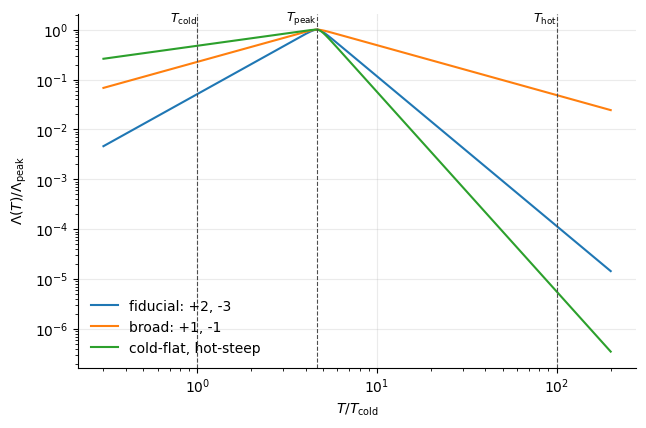

In [3]:
fig, ax = plt.subplots()

for slope_lo, slope_hi, label in [
    (2.0, -3.0, "fiducial: +2, -3"),
    (1.0, -1.0, "broad: +1, -1"),
    (0.5, -4.0, "cold-flat, hot-steep"),
]:
    p = replace(CoolingParams(), lambda_slope_lo=slope_lo, lambda_slope_hi=slope_hi)
    ax.loglog(T_GRID / T_COLD, lambda_trml(T_GRID, p) / p.lambda_peak, label=label)

for value, name in [(T_COLD, r"$T_{\text{cold}}$"), (T_PEAK, r"$T_{\text{peak}}$"), (T_HOT, r"$T_{\text{hot}}$")]:
    ax.axvline(value / T_COLD, color="0.3", lw=0.8, ls="--")
    ax.text(value / T_COLD, 1.15, name, rotation=0, va="bottom", ha="right", fontsize=9)

ax.set_xlabel(r"$T / T_{\text{cold}}$")
ax.set_ylabel(r"$\Lambda(T) / \Lambda_{\text{peak}}$")
ax.legend(frameon=False)
plt.show()

## Shape controls: smoothing width

`lambda_smooth_width` is a width in `ln(T/T_peak)`. Smaller values approach a sharp broken power law. Larger values spread the zero-slope peak over a wider temperature interval.

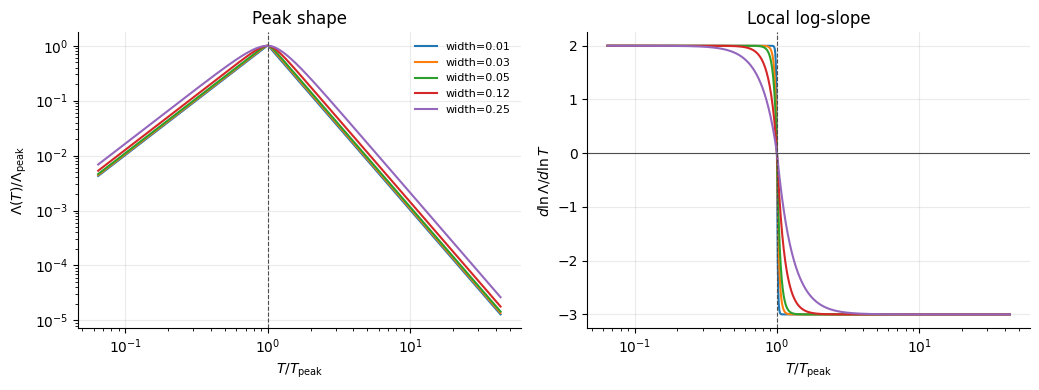

In [4]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10.5, 4.0), sharex=True)

for width in [0.01, 0.03, 0.05, 0.12, 0.25]:
    p = replace(CoolingParams(), lambda_smooth_width=width)
    lam = lambda_trml(T_GRID, p) / p.lambda_peak
    slope = np.gradient(np.log(lam), np.log(T_GRID))
    ax0.loglog(T_GRID / T_PEAK, lam, label=f"width={width:g}")
    ax1.semilogx(T_GRID / T_PEAK, slope)

ax0.axvline(1.0, color="0.3", lw=0.8, ls="--")
ax1.axvline(1.0, color="0.3", lw=0.8, ls="--")
ax1.axhline(0.0, color="0.3", lw=0.8)
ax0.set_xlabel(r"$T / T_{\text{peak}}$")
ax1.set_xlabel(r"$T / T_{\text{peak}}$")
ax0.set_ylabel(r"$\Lambda(T) / \Lambda_{\text{peak}}$")
ax1.set_ylabel(r"$d \ln \Lambda / d \ln T$")
ax0.set_title("Peak shape")
ax1.set_title("Local log-slope")
ax0.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## Amplitude choices

There are three equivalent ways to set the amplitude:

- Direct: specify `lambda_peak` in code units.
- Cooling-time: specify `t_cool_0` at `T_peak` on the initial pressure curve.
- Dimensionless: specify `xi = t_shear / t_cool_0`.

If `lambda_peak` is present, it wins. The code prints the effective `t_cool_0` and `xi`.

mode                      lambda_peak       t_cool_0         xi_eff
direct lambda_peak               0.25      0.0129178         120.02
t_cool_0=0.08                0.040368           0.08        19.3798
xi=20                       0.0416598      0.0775194             20


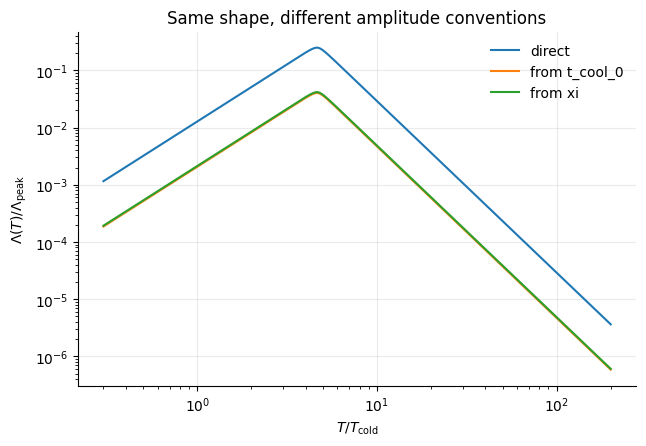

In [5]:
base = CoolingParams()
direct = replace(base, lambda_peak=0.25)
by_tcool = with_tcool0(base, t_cool_0=0.08)
by_xi = with_xi(base, xi=20.0)

rows = [
    ("direct lambda_peak", direct.lambda_peak, cooling_time_at_peak(direct), T_SHEAR / cooling_time_at_peak(direct)),
    ("t_cool_0=0.08", by_tcool.lambda_peak, cooling_time_at_peak(by_tcool), T_SHEAR / cooling_time_at_peak(by_tcool)),
    ("xi=20", by_xi.lambda_peak, cooling_time_at_peak(by_xi), T_SHEAR / cooling_time_at_peak(by_xi)),
]

print(f"{'mode':<22} {'lambda_peak':>14} {'t_cool_0':>14} {'xi_eff':>14}")
for row in rows:
    print(f"{row[0]:<22} {row[1]:14.6g} {row[2]:14.6g} {row[3]:14.6g}")

fig, ax = plt.subplots()
for params, label in [(direct, "direct"), (by_tcool, "from t_cool_0"), (by_xi, "from xi")]:
    ax.loglog(T_GRID / T_COLD, lambda_trml(T_GRID, params), label=label)
ax.set_xlabel(r"$T / T_{\text{cold}}$")
ax.set_ylabel(r"$\Lambda(T) / \Lambda_{\text{peak}}$")
ax.set_title("Same shape, different amplitude conventions")
ax.legend(frameon=False)
plt.show()

## Temperature gates

`cool_T_min` and `cool_T_max` are hard gates. Both cooling and heating are zero outside the active window.

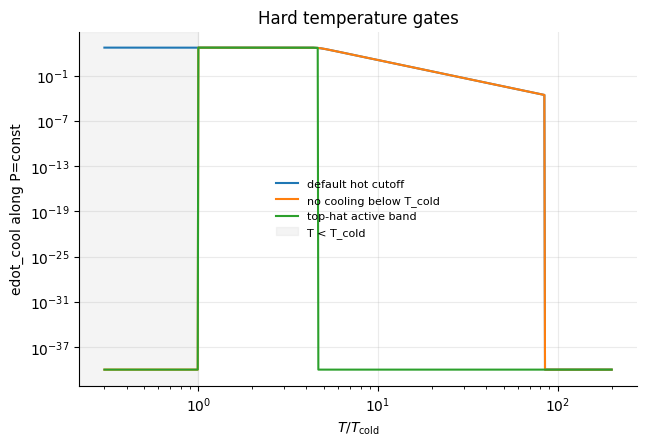

In [6]:
fig, ax = plt.subplots()

windows = [
    (0.0, 0.85 * T_HOT, "default hot cutoff"),
    (T_COLD, 0.85 * T_HOT, "no cooling below T_cold"),
    (T_COLD, T_PEAK, "top-hat active band"),
]

for Tmin, Tmax, label in windows:
    p = replace(CoolingParams(), cool_T_min=Tmin, cool_T_max=Tmax)
    edot_cool, _, _ = evaluate_cooling(PGAS_0 / T_GRID, T_GRID, p)
    ax.loglog(T_GRID / T_COLD, np.maximum(edot_cool, 1.0e-40), label=label)

ax.axvspan(0.0, 1.0, color="0.8", alpha=0.2, label="T < T_cold")
ax.set_xlabel(r"$T / T_{\text{cold}}$")
ax.set_ylabel("edot_cool along P=const")
ax.set_title("Hard temperature gates")
ax.legend(frameon=False, fontsize=8)
plt.show()

## Heating modes

- `off`: `Gamma(T) = 0`.
- `direct`: use `heat_gamma` as the value of `Gamma` at `heat_gamma_T_ref`.
- `balance_cold`: choose `heat_gamma` so the cold phase has zero net cooling, including any `heat_gamma_T_slope`.

The plot below follows the initial pressure curve, so `rho = P / T`.

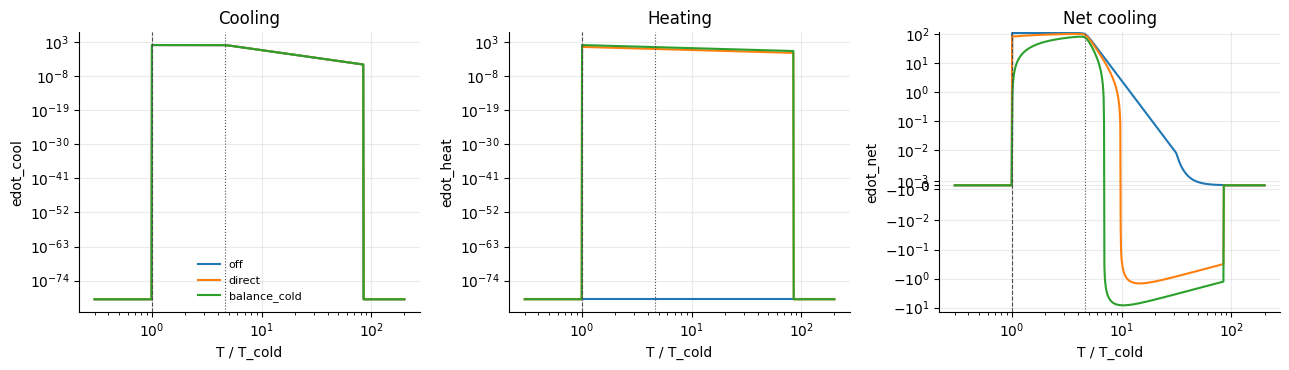

balance_cold heat_gamma = 1.06925
Gamma(T_cold) = 1.06925


In [7]:
curve = with_xi(CoolingParams(cool_T_min=T_COLD), xi=100.0)
balance = with_balance_cold(curve)
direct = replace(curve, heat_gamma=0.25 * balance.heat_gamma)
rho_pressure_curve = PGAS_0 / T_GRID

fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.8), sharex=True)
for params, label, color in [
    (curve, "off", "C0"),
    (direct, "direct", "C1"),
    (balance, "balance_cold", "C2"),
]:
    edot_cool, edot_heat, edot_net = evaluate_cooling(rho_pressure_curve, T_GRID, params)
    axes[0].loglog(T_GRID / T_COLD, np.maximum(edot_cool, 1.0e-80), color=color, label=label)
    axes[1].loglog(T_GRID / T_COLD, np.maximum(edot_heat, 1.0e-80), color=color, label=label)
    axes[2].semilogx(T_GRID / T_COLD, edot_net, color=color, label=label)

for ax in axes:
    ax.axvline(1.0, color="0.3", lw=0.8, ls="--")
    ax.axvline(T_PEAK / T_COLD, color="0.3", lw=0.8, ls=":")
    ax.set_xlabel("T / T_cold")
axes[0].set_ylabel("edot_cool")
axes[1].set_ylabel("edot_heat")
axes[2].set_ylabel("edot_net")
axes[2].set_yscale("symlog", linthresh=max(np.nanmax(np.abs(evaluate_cooling(rho_pressure_curve, T_GRID, balance)[2])) * 1.0e-4, 1.0e-80))
axes[0].set_title("Cooling")
axes[1].set_title("Heating")
axes[2].set_title("Net cooling")
axes[0].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

print(f"balance_cold heat_gamma = {balance.heat_gamma:.6g}")
print(f"Gamma(T_cold) = {gamma_trml(np.array([T_COLD]), balance)[0]:.6g}")

## Optional temperature dependence in Gamma(T)

`heat_gamma_T_slope` adds a power-law temperature dependence to the heating coefficient:

\[
\Gamma(T)=\Gamma_{\rm ref}\left(T/T_{\rm ref}\right)^a.
\]

In inputs, `heat_gamma` is `Gamma_ref`, `heat_gamma_T_ref` is `T_ref`, and `heat_gamma_T_slope` is `a`. The default `a=0` is constant heating.

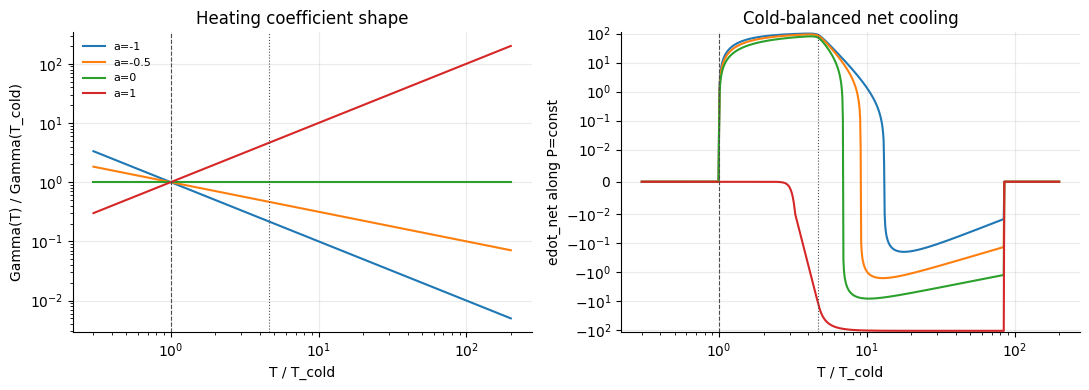

In [8]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.0, 4.0), sharex=True)

for slope, label in [(-1.0, "a=-1"), (-0.5, "a=-0.5"), (0.0, "a=0"), (1.0, "a=1")]:
    p = replace(balance, heat_gamma_T_slope=slope)
    p = with_balance_cold(p)
    gamma_vals = gamma_trml(T_GRID, p)
    _, _, edot_net = evaluate_cooling(rho_pressure_curve, T_GRID, p)
    ax0.loglog(T_GRID / T_COLD, gamma_vals / gamma_trml(np.array([T_COLD]), p)[0], label=label)
    ax1.semilogx(T_GRID / T_COLD, edot_net, label=label)

for ax in (ax0, ax1):
    ax.axvline(1.0, color="0.3", lw=0.8, ls="--")
    ax.axvline(T_PEAK / T_COLD, color="0.3", lw=0.8, ls=":")
    ax.set_xlabel("T / T_cold")
ax0.set_ylabel("Gamma(T) / Gamma(T_cold)")
ax1.set_ylabel("edot_net along P=const")
ax1.set_yscale("symlog", linthresh=1.0e-2)
ax0.set_title("Heating coefficient shape")
ax1.set_title("Cold-balanced net cooling")
ax0.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## Density scaling

At fixed temperature, cooling scales as `n^2` while heating scales as `n`. Temperature-dependent `Gamma(T)` changes the temperature shape, but at any chosen temperature the density scaling remains linear for heating.

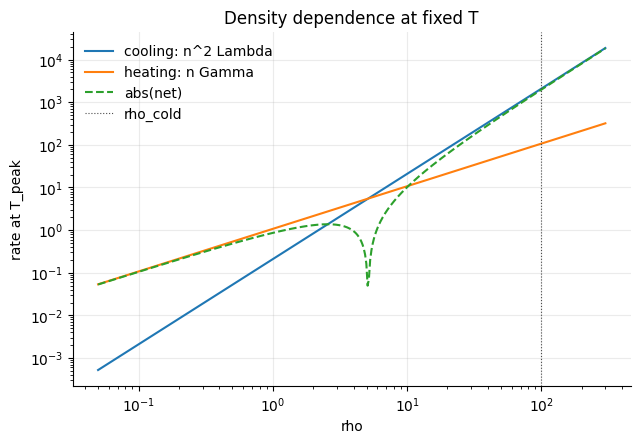

In [9]:
params = with_balance_cold(with_xi(CoolingParams(cool_T_min=T_COLD), xi=100.0))
rho_grid = np.geomspace(0.05, 300.0, 400)
T_fixed = T_PEAK
edot_cool, edot_heat, edot_net = evaluate_cooling(rho_grid, T_fixed, params)

fig, ax = plt.subplots()
ax.loglog(rho_grid, edot_cool, label="cooling: n^2 Lambda")
ax.loglog(rho_grid, edot_heat, label="heating: n Gamma")
ax.loglog(rho_grid, np.abs(edot_net), ls="--", label="abs(net)")
ax.axvline(RHO_0 * CHI, color="0.3", lw=0.8, ls=":", label="rho_cold")
ax.set_xlabel("rho")
ax.set_ylabel("rate at T_peak")
ax.set_title("Density dependence at fixed T")
ax.legend(frameon=False)
plt.show()

## Deprecated beta aliases

The parser still accepts old `beta_lo`, `beta_hi` keys with a warning. They map by sign:

`lambda_slope_lo = -beta_lo`, `lambda_slope_hi = -beta_hi`.

The preferred input should use `lambda_slope_lo` and `lambda_slope_hi` directly.

max relative difference between new slopes and legacy aliases: 0.000e+00


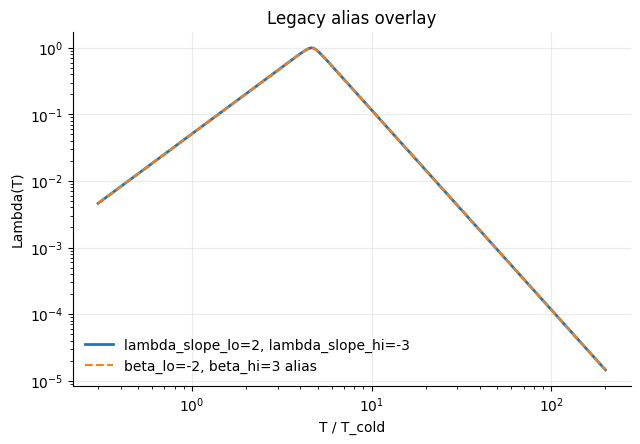

In [10]:
new_style = CoolingParams(lambda_slope_lo=2.0, lambda_slope_hi=-3.0)
legacy_style = from_legacy_beta(CoolingParams(), beta_lo=-2.0, beta_hi=3.0)
relative_difference = np.max(
    np.abs(lambda_trml(T_GRID, new_style) - lambda_trml(T_GRID, legacy_style)) /
    np.maximum(lambda_trml(T_GRID, new_style), 1.0e-300)
)
print(f"max relative difference between new slopes and legacy aliases: {relative_difference:.3e}")

fig, ax = plt.subplots()
ax.loglog(T_GRID / T_COLD, lambda_trml(T_GRID, new_style), lw=2, label="lambda_slope_lo=2, lambda_slope_hi=-3")
ax.loglog(T_GRID / T_COLD, lambda_trml(T_GRID, legacy_style), ls="--", label="beta_lo=-2, beta_hi=3 alias")
ax.set_xlabel("T / T_cold")
ax.set_ylabel("Lambda(T)")
ax.set_title("Legacy alias overlay")
ax.legend(frameon=False)
plt.show()

## Input snippets

Preferred direct-amplitude setup:

```ini
lambda_slope_lo = 2.0
lambda_slope_hi = -3.0
lambda_smooth_width = 0.05
T_peak_over_T_cold = 4.64
cool_T_min = 0.0
cool_T_max = 0.85
lambda_peak = 1.0e-50
heating_mode = off
```

Preferred xi-derived setup:

```ini
lambda_slope_lo = 2.0
lambda_slope_hi = -3.0
lambda_smooth_width = 0.05
T_peak_over_T_cold = 4.64
cool_T_min = 0.0
cool_T_max = 0.85
xi = 100.0
heating_mode = off
```

Cold-balanced heating with temperature-dependent `Gamma`:

```ini
cool_T_min = 0.01     # must include T_cold for chi=100, T_hot=1
heating_mode = balance_cold
heat_gamma_T_ref = 0.01
heat_gamma_T_slope = -0.75
```

Direct temperature-dependent heating:

```ini
heating_mode = direct
heat_gamma = 1.0e-4
heat_gamma_T_ref = 0.01
heat_gamma_T_slope = 1.0
```


## Exercise

Change one of these choices and rerun the next cell:

- Make `lambda_smooth_width` larger.
- Move `cool_T_max` below `T_peak` and observe the peak disappear.
- Set `heat_gamma_T_slope` to a positive or negative value and compare the heating curve.


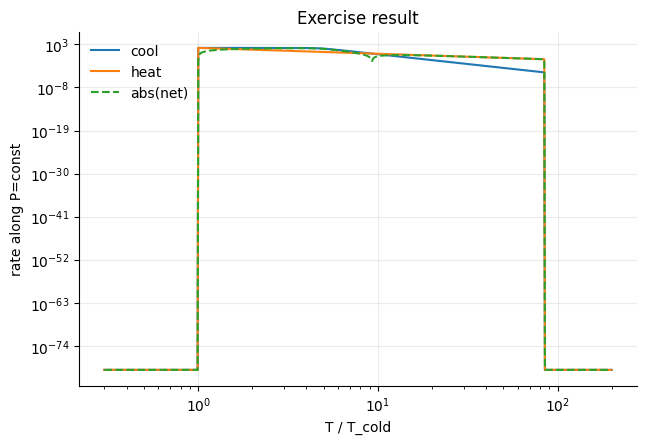

In [11]:
exercise = replace(
    with_xi(CoolingParams(), xi=100.0),
    lambda_smooth_width=0.12,
    cool_T_min=T_COLD,
    cool_T_max=0.85 * T_HOT,
    heat_gamma=0.0,
    heat_gamma_T_ref=T_COLD,
    heat_gamma_T_slope=-0.5,
)
exercise = with_balance_cold(exercise)
rho_pressure_curve = PGAS_0 / T_GRID
edot_cool, edot_heat, edot_net = evaluate_cooling(rho_pressure_curve, T_GRID, exercise)

fig, ax = plt.subplots()
ax.loglog(T_GRID / T_COLD, np.maximum(edot_cool, 1.0e-80), label="cool")
ax.loglog(T_GRID / T_COLD, np.maximum(edot_heat, 1.0e-80), label="heat")
ax.loglog(T_GRID / T_COLD, np.maximum(np.abs(edot_net), 1.0e-80), ls="--", label="abs(net)")
ax.set_xlabel("T / T_cold")
ax.set_ylabel("rate along P=const")
ax.set_title("Exercise result")
ax.legend(frameon=False)
plt.show()

## Pitfalls and checks

- `cool_T_min` and `cool_T_max` gate heating too, not just cooling.
- `balance_cold` fails if `T_cold` is outside the active temperature window.
- `lambda_peak` is in code units. If it is specified, it overrides `xi` and `t_cool_0`.
- `heat_gamma` is the value of `Gamma(T)` at `heat_gamma_T_ref`; the default `heat_gamma_T_slope=0` makes it constant.
- The slopes are slopes of `Lambda(T)`, not of pressure-dependent cooling.
- For production runs, use the C++ helper output printed at startup to confirm `lambda_peak`, `t_cool_0`, `xi`, `heat_gamma`, `heat_gamma_T_ref`, and `heat_gamma_T_slope`.